In [51]:
import astropy.units as un
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import matplotlib.font_manager as font_manager

font_path = '/home/mattias/AIPS/sn2012au/paper_figures/AVHersheyComplexMedium.ttf'  # Your fontpath goes here
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
c1,c2,c3,c4,c5,c6,c7,c8,c9 = colors


## **1: Determining Distribution of Parameters**

In [2]:
path_to_csv = 'binaries.csv'
df = pd.read_csv(path_to_csv)

columns_names = df.columns.tolist()
print(columns_names)


['asassn_name', 'raj2000', 'dej2000', 'requivsumfrac', 'teffratio', 'period', 'ecc', 'per0', 'incl', 't0supconj', 'alarm_g', 'alarm_v', 'reduced_chi2', 'median_g', 'median_v', 'amplitude_g', 'amplitude_v', 'rot_flag', 'phot_g_mean_mag', 'bp_rp', 'mwdust_abp', 'mwdust_arp', 'mwdust_ag', 'mwdust_av', 'rpgeo', 'parallax_over_error', 'source_id', 'bp_rp_corrected', 'absolute_g', 'gaia_filter', 'heasarc_reference_id', 'xray_observatory', 'xray_exposure', 'xray_separation', 'xray_luminosity', 'state', 'xray_flag']


In [151]:
# Extract parameters of interest
sources = np.asarray(df['asassn_name'])
requivsumfrac = np.asarray(df['requivsumfrac'])
teff = np.asarray(df['teffratio'])
period = np.asarray(df['period'])
ecc = np.asarray(df['ecc'])
incl = np.asarray(df['incl'])
per0 = np.asarray(df['per0'])

first_quartile = np.percentile(ecc, 25)

mask = np.array(ecc<0.0001)#np.logical_and(per0<180, teff>0.8, period<10)
requivsumfrac = requivsumfrac[mask]
teff = teff[mask]
period = period[mask]
ecc = ecc[mask]
incl = incl[mask]
per0 = per0[mask]


mask2 = np.logical_or(teff<.475, teff>.525)
# mask2 =  np.array(teff<1.5)
requivsumfrac = requivsumfrac[mask2]
teff = teff[mask2]
period = period[mask2]
ecc = ecc[mask2]
incl = incl[mask2]
per0 = per0[mask2]


mask3 = np.array(period<5)
requivsumfrac = requivsumfrac[mask3]
teff = teff[mask3]
period = period[mask3]
ecc = ecc[mask3]
incl = incl[mask3]
per0 = per0[mask3]

# Recast and make a pair plot
npoints = 1000
array = np.swapaxes(np.array([requivsumfrac,teff,period,ecc,incl])[:,:npoints], 0,1)
truncated_arr = pd.DataFrame(array, columns=['per0', 'Teff', 'P', 'e', 'i'])


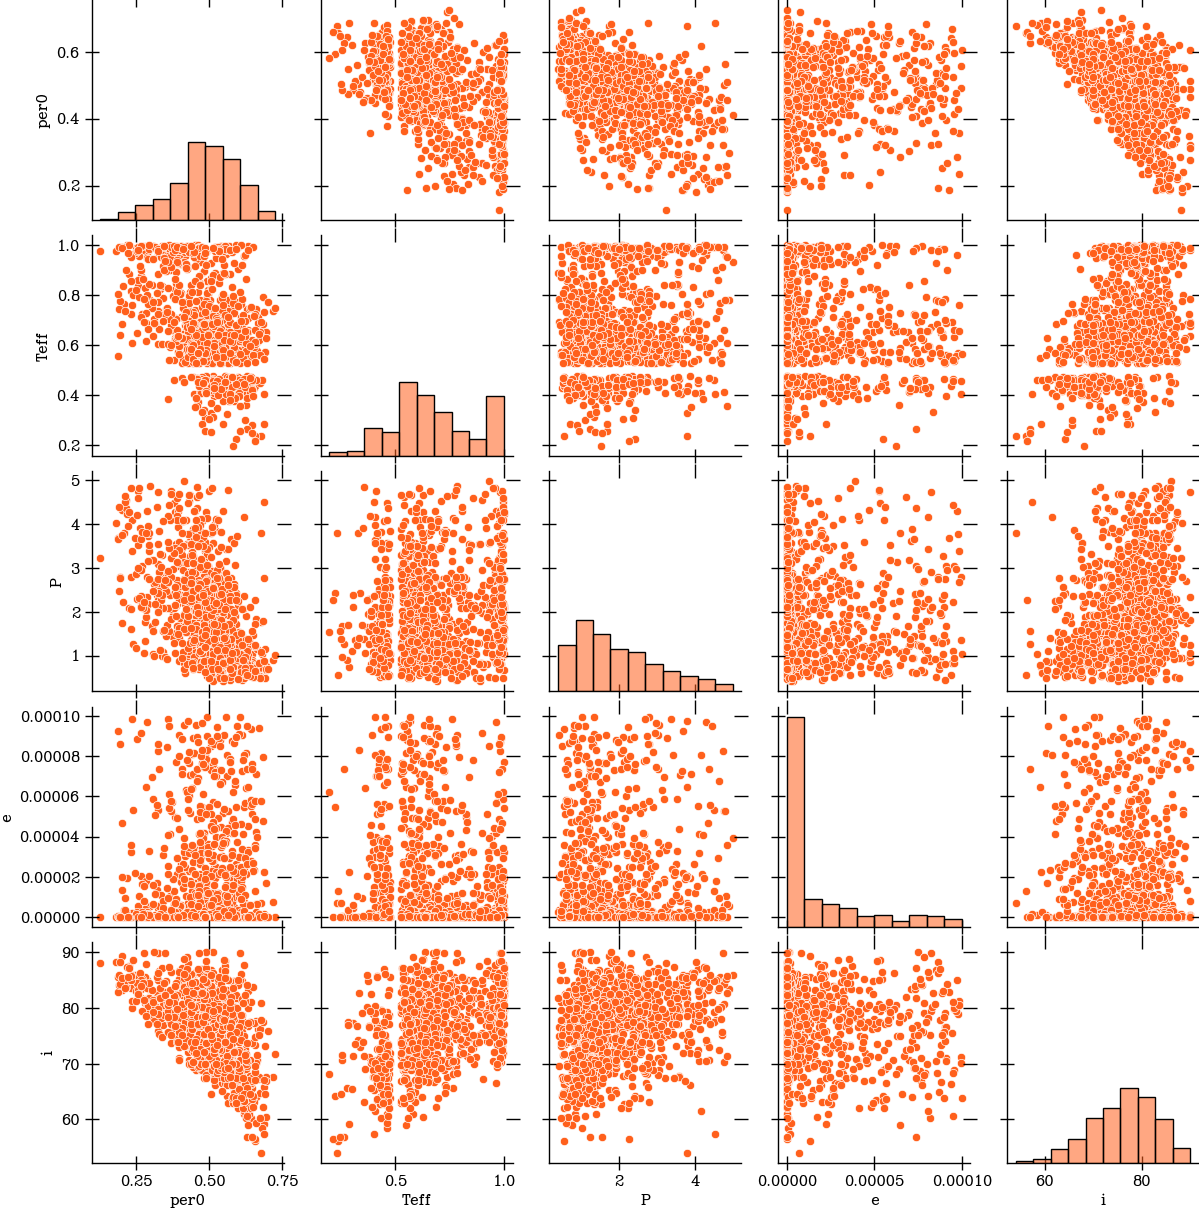

In [152]:
sns.pairplot(truncated_arr, diag_kind = "hist", 
             diag_kws = {'alpha':0.55, 'bins':10})  # 'scatter' for scatter plots

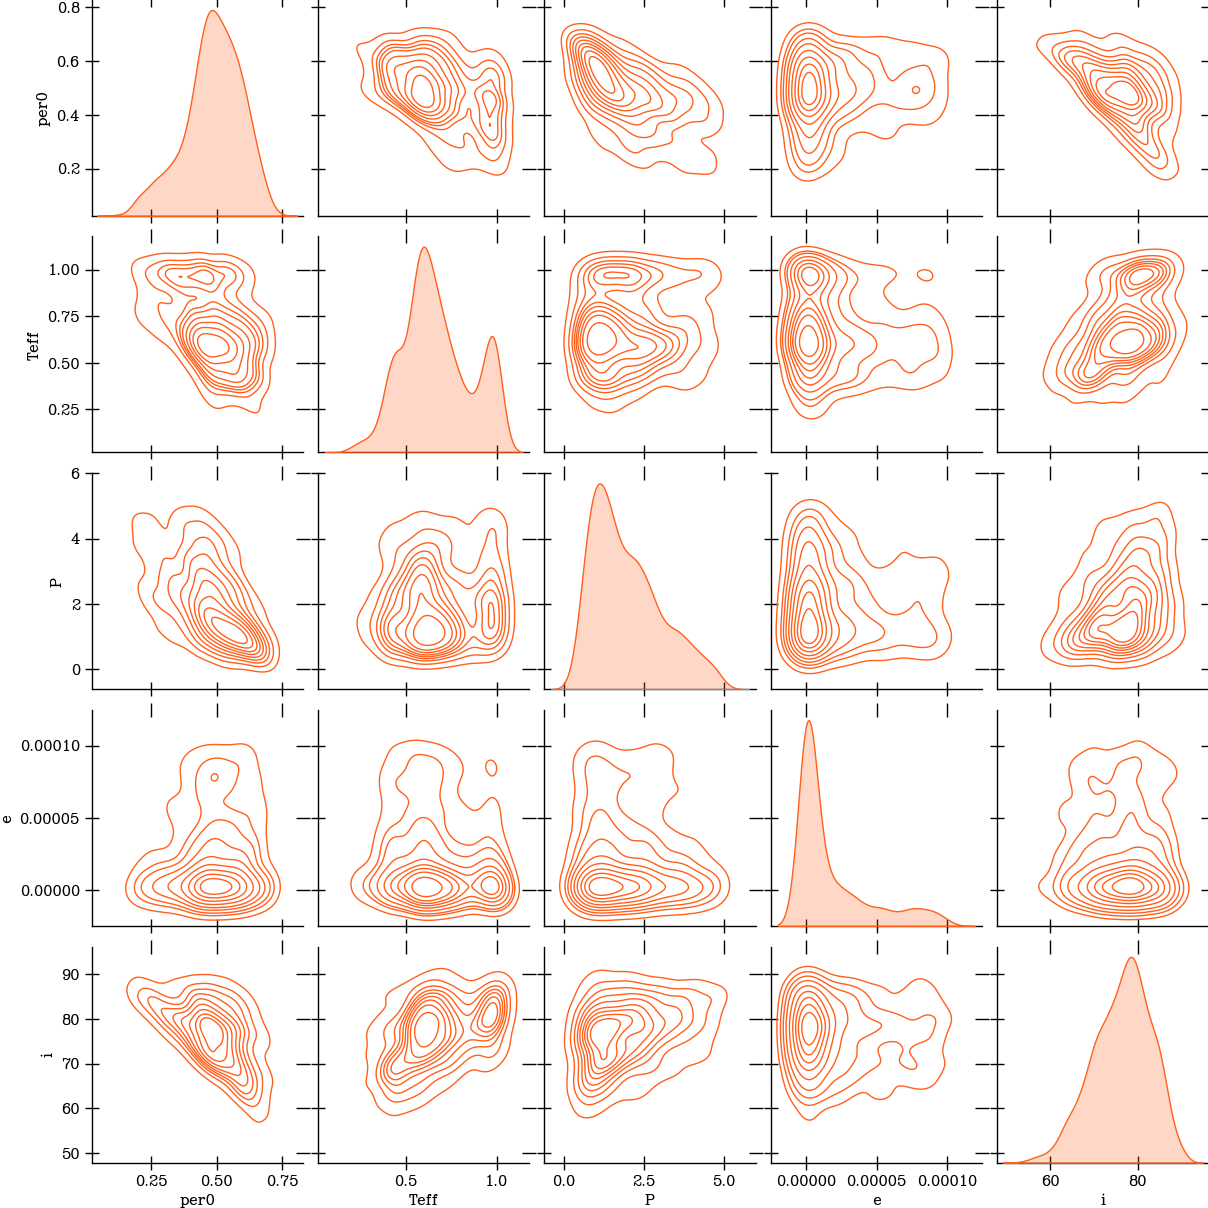

In [153]:
sns.pairplot(truncated_arr,kind='kde')  # 'scatter' for scatter plots?

In [157]:
# Extract parameters of interest
sources = np.asarray(df['asassn_name'])
requivsumfrac = np.asarray(df['requivsumfrac'])
teff = np.asarray(df['teffratio'])
period = np.asarray(df['period'])
ecc = np.asarray(df['ecc'])
incl = np.asarray(df['incl'])
per0 = np.asarray(df['per0'])

first_quartile = np.percentile(ecc, 25)

mask = np.array(ecc<0.0001)#np.logical_and(per0<180, teff>0.8, period<10)
requivsumfrac = requivsumfrac[mask]
teff = teff[mask]
period = period[mask]
ecc = ecc[mask]
incl = incl[mask]
per0 = per0[mask]


mask2 = np.logical_and(teff>.65-0.01, teff<.65+0.01)
# mask2 =  np.array(teff<1.5)
requivsumfrac = requivsumfrac[mask2]
teff = teff[mask2]
period = period[mask2]
ecc = ecc[mask2]
incl = incl[mask2]
per0 = per0[mask2]


mask3 = np.array(period<5)
requivsumfrac = requivsumfrac[mask3]
teff = teff[mask3]
period = period[mask3]
ecc = ecc[mask3]
incl = incl[mask3]
per0 = per0[mask3]

# Recast and make a pair plot
npoints = 1000
array = np.swapaxes(np.array([requivsumfrac,teff,period,ecc,incl])[:,:npoints], 0,1)
truncated_arr = pd.DataFrame(array, columns=['requivsumfrac', 'Teff', 'P', 'e', 'i'])


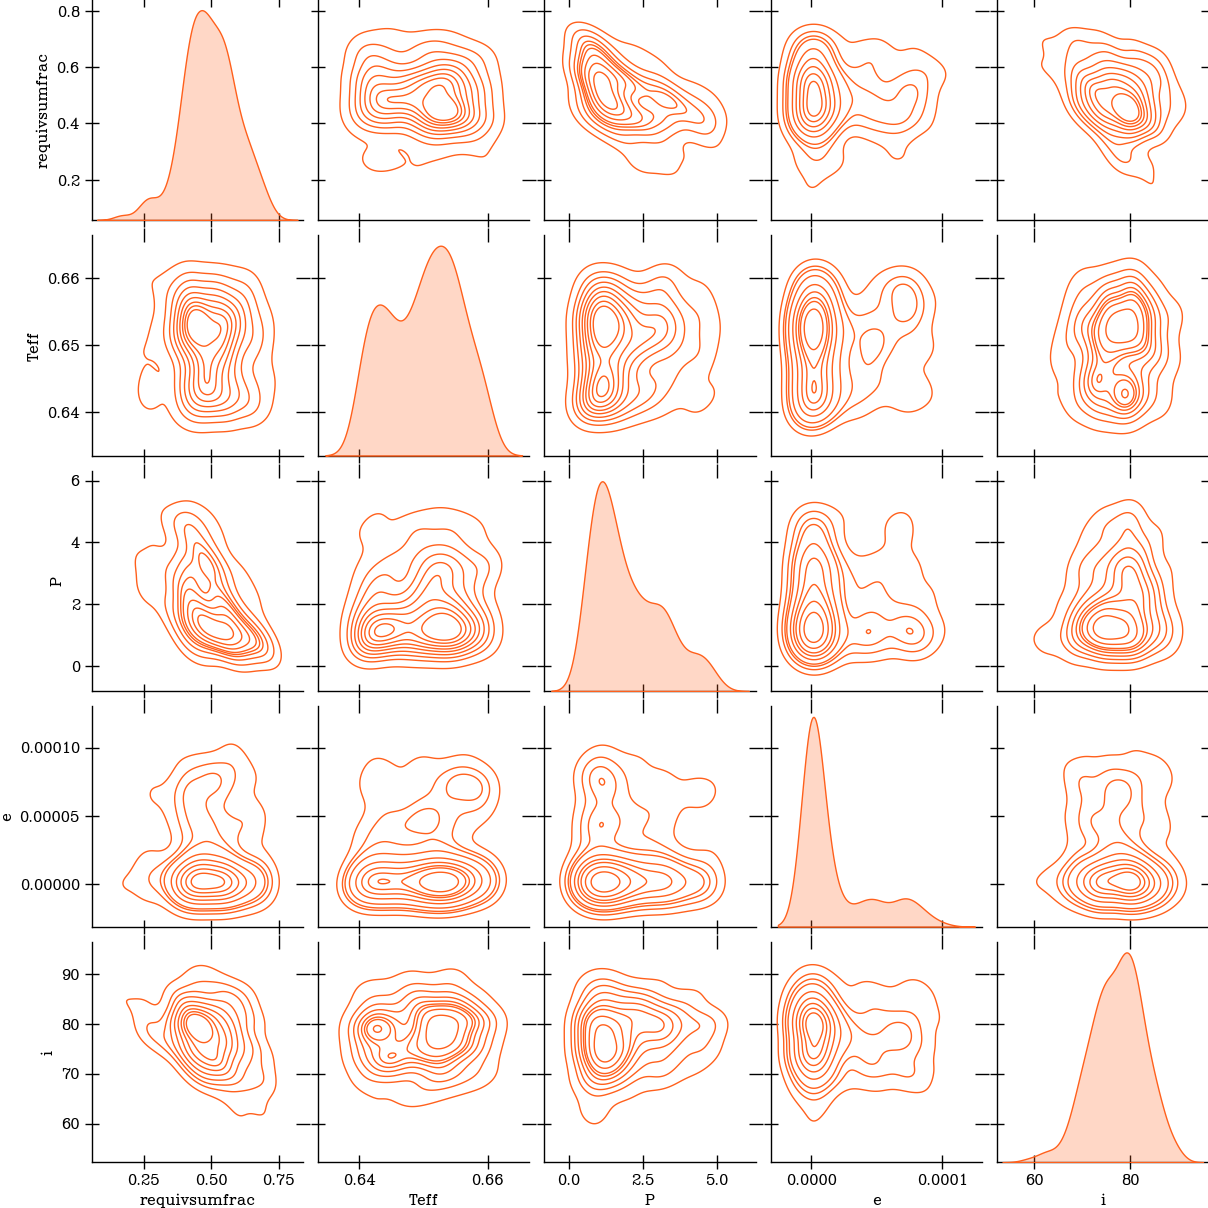

In [158]:
sns.pairplot(truncated_arr, kind='kde')  # 'scatter' for scatter plots

# **Simulating Missing Data**

In [2]:
import numpy as np
import astropy.units as un
import matplotlib.pyplot as plt

In the following section, we aim to take a lightcurve, defined by an input of timestamps with corresponding fluxes, and perform a set of modifications to the lightcurve, simulating realistic missing data scenarios. First, let us construct a set of simulated lightcurves. For simplicity, we will define a sine wave with an arbitrary amplitude.

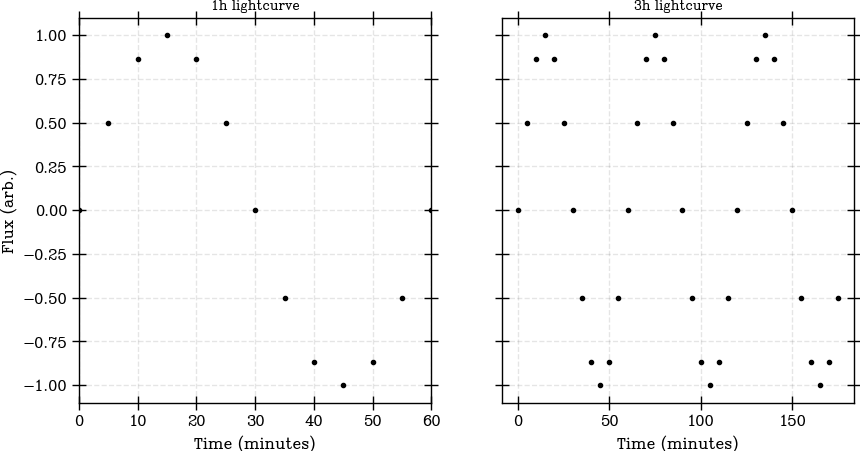

In [3]:
# Generate simulation observation
time_step = 5*un.min # Sampling rate 
period = 1 * un.hour # Period of orbit
t_arr = np.arange(0,3*period.to('min').value,time_step.to('min').value)*un.min
omega = (2*np.pi/period).to('Hz')*un.rad
flux_timestream = np.sin((omega*t_arr).decompose())

fig, (ax1,ax2) = plt.subplots(figsize=(10,5), nrows=1,ncols=2,sharey=True)
ax1.plot(t_arr, flux_timestream, '.',color='black',ls='none')
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('Flux (arb.)')
ax1.grid(alpha=0.1)
ax1.set_xlim(0,60)
ax1.set_title('1h lightcurve')

ax2.plot(t_arr, flux_timestream, '.',color='black',ls='none')
ax2.set_xlabel('Time (minutes)')
ax2.grid(alpha=0.1)
ax2.set_title('3h lightcurve')


plt.show()


With a basic timestream in hand, we can now define a set of function to remove some data. 

### **Periodic Missing Data**

The first contamination we consider is periodically missing data (e.g. the telescope goes on a scheduled maintenance every 18 hours, for 4 hours).  

Assumptions of timestream: 
- Time starts at 0 (e.g. all data is relative to an initial time start, not absolute time)

In [4]:
def remove_data_periodic(t_arr, fluxes, t0, dur, p, fill_nan=False):
    '''
    A function to periodically remove data from a given timestream. 
    Parameters: 
    -----------
    t_arr: ndarray, astropy.units 
        Astropy array of timestamps
    fluxes: ndarray
        Array of fluxes corresponding to flux of source at t_arr
    t0: astropy.Quantity
        Time from start to begin periodically removing data. Assumes that t0 = 0. 
    dur: astropy.Quantity 
        Duration for which you miss data for, per block. 
    p: astropy.Quantity
        Period over which to begin removing data, relative t0. 
    fill_nan: bool
        If True, replace removed data with nans. If False, returns truncated array with data removed altogether. 

    Returns: 
    --------
    t_arr_masked: ndarray, astropy.units 
        Masked array of timestamps 
    fluxes_masked: ndarray
        Masked array of fluxes 
    mask: ndarray
        Final mask. 
    '''

    # Determine length of timestream, number of blocks to mask  
    tot_time = t_arr[-1]
    n_blocks = np.floor(((tot_time - t0) / p).decompose()).value

    # Initialize mask
    mask = np.logical_or(t_arr < t0, t_arr > t0 + dur)

    # Iterates through each block and creates a mask, multiplying with previous masks to stack them together
    for i in range(1,int(n_blocks)+1):
        i_mask = np.logical_or(t_arr < t0+i*p,t_arr > t0 + dur + i*p)
        mask*=i_mask

    if fill_nan: 
        t_arr[~mask]=np.nan
        fluxes[~mask]=np.nan
        return t_arr, fluxes, mask
        
    t_arr_masked=t_arr[mask]
    fluxes_masked=fluxes[mask]

    print('Initial array length:', len(t_arr))
    print('Final array length:', len(t_arr_masked))
    
    return t_arr_masked, fluxes_masked, mask

In [7]:
# Define test parameters
t0 = 30 * un.min
dur = 15*un.min
p = 1*un.hour 

t_arr_masked, fluxes_masked, mask = remove_data_periodic(t_arr, flux_timestream, t0, dur, p)

Initial array length: 36
Final array length: 24


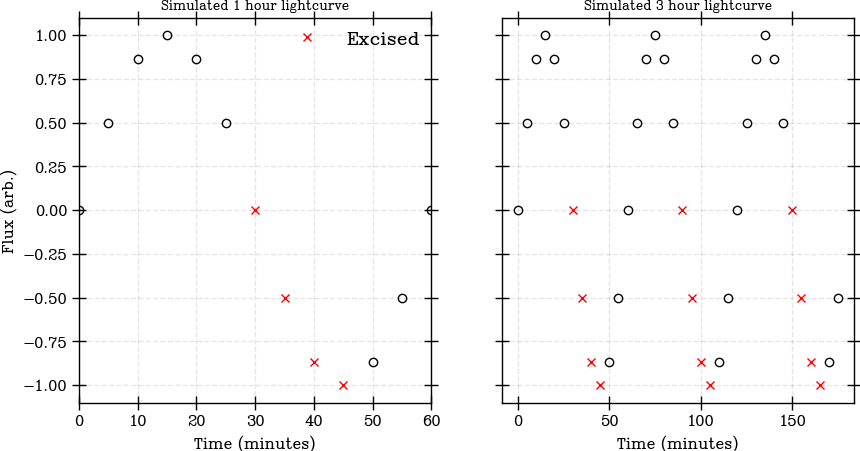

In [8]:
# Generate simulation observation
fig, (ax1,ax2) = plt.subplots(figsize=(10,5), nrows=1,ncols=2,sharey=True)
ax1.plot(t_arr_masked, fluxes_masked, 'o',mew=1,mfc='none',color='black',ls='none')
ax1.plot(t_arr[~mask], flux_timestream[~mask],'x',color='red', label='Excised')
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('Flux (arb.)')
ax1.grid(alpha=0.1)
ax1.set_xlim(0,60)
ax1.set_title('Simulated 1 hour lightcurve')
ax1.legend(fontsize=16)


ax2.plot(t_arr_masked, fluxes_masked, 'o',mew=1,mfc='none',color='black',ls='none')
ax2.plot(t_arr[~mask], flux_timestream[~mask],'x',color='red', label='Excised')
ax2.set_xlabel('Time (minutes)')
ax2.grid(alpha=0.1)
ax2.set_title('Simulated 3 hour lightcurve')


plt.show()


### **Pseudo-random data removal**

Now we wish to simulate data removal that is not periodic. To do so, we will draw $t0$ and $dur$ from a sample set of distributions which we define below.

In [9]:
def remove_data_random(t_arr, fluxes, dur_params, f,fill_nan=False, verbose=False):

    mean,std=dur_params

    # On average, 10% of the data will be flagged 
    tot_time = t_arr[-1] - t_arr[0]
    n_blocks = np.floor(((tot_time) / (f*mean)).decompose()).value

    # Generate initial sample t0 and duration 
    t0_sample = np.random.uniform(low=0,high=np.max(t_arr).to('min').value)
    dur_sample = np.random.normal(loc=mean.to('min').value,scale=std.to('min').value)

    assert t0_sample >=0
    
    while dur_sample < 0: 
        dur_sample = np.random.normal(loc=mean.to('min').value,scale=std.to('min').value)

    t0_sample*=un.min
    dur_sample*=un.min

    # Initialize mask
    mask = np.logical_or(t_arr < t0_sample, t_arr > t0_sample + dur_sample)

    # Iterates through each block and creates a mask, multiplying with previous masks to stack them together
    for i in range(1,int(n_blocks)+1):

        t0_sample = np.random.uniform(low=0,high=np.max(t_arr).to('min').value)
        dur_sample = np.random.normal(loc=mean.to('min').value,scale=std.to('min').value)
    
        assert t0_sample >=0
        
        while dur_sample < 0: 
            dur_sample = np.random.normal(loc=mean.to('min').value,scale=std.to('min').value)

        t0_sample*=un.min
        dur_sample*=un.min
        
        i_mask = np.logical_or(t_arr < t0_sample,t_arr > t0_sample + dur_sample )
        mask*=i_mask


    if fill_nan: 
        t_arr[~mask]=np.nan
        fluxes[~mask]=np.nan
        return t_arr, fluxes, mask
        
    t_arr_masked=t_arr[mask]
    fluxes_masked=fluxes[mask]

    fraction_flagged = (len(t_arr) - len(t_arr_masked))/len(t_arr)
    
    if verbose: 
        print('Initial array length:', len(t_arr))
        print('Final array length:', len(t_arr_masked))
    
    return t_arr_masked, fluxes_masked, mask, fraction_flagged, n_blocks

    

    

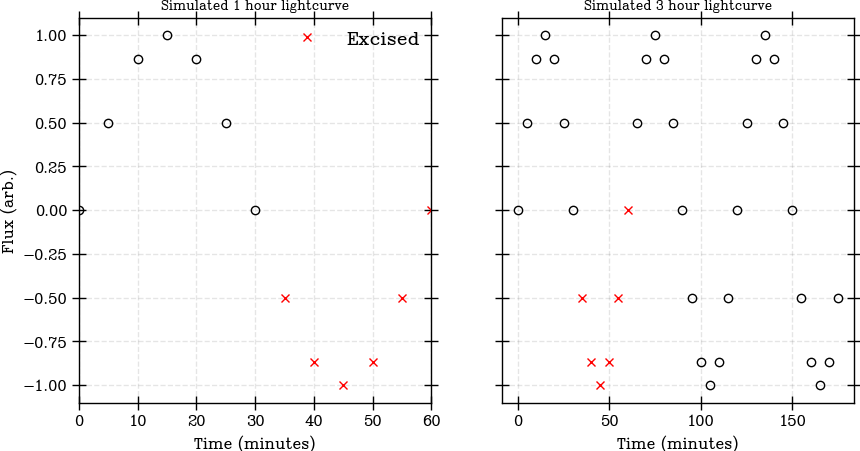

In [11]:
dur_params = (20*un.min,45*un.min)
f = 6
t_arr_masked, fluxes_masked, mask,_,_ = remove_data_random(t_arr, flux_timestream, dur_params, f=f,fill_nan=False)

# Generate simulation observation
fig, (ax1,ax2) = plt.subplots(figsize=(10,5), nrows=1,ncols=2,sharey=True)
ax1.plot(t_arr_masked, fluxes_masked, 'o',mew=1,mfc='none',color='black',ls='none')
ax1.plot(t_arr[~mask], flux_timestream[~mask],'x',color='red', label='Excised')
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('Flux (arb.)')
ax1.grid(alpha=0.1)
ax1.set_xlim(0,60)
ax1.set_title('Simulated 1 hour lightcurve')
ax1.legend(fontsize=16)


ax2.plot(t_arr_masked, fluxes_masked, 'o',mew=1,mfc='none',color='black',ls='none')
ax2.plot(t_arr[~mask], flux_timestream[~mask],'x',color='red', label='Excised')
ax2.set_xlabel('Time (minutes)')
ax2.grid(alpha=0.1)
ax2.set_title('Simulated 3 hour lightcurve')


plt.show()


Now that we have a function to excise the data, we can look at the distribution of flagged data. We want to avoid flagging too much data, but also want to flag enough data to be "realistic". We can do this by computing many iterations and looking at the distribution of flagged data. 

In [10]:
def get_distribution_of_flagged_data(t_arr, fluxes, dur_params, f,nsample=1e4):

    flagged_data = []
    for i in range(nsample): 
        t_arr_masked, fluxes_masked, mask, fraction_flagged,_ = remove_data_random(t_arr, fluxes, dur_params,f)
        flagged_data.append(fraction_flagged)

    flagged_data = np.asarray(flagged_data)

    return flagged_data
    
    
    

In [12]:
dur_params = (20*un.min,45*un.min)
f = 6
flagged_samples = get_distribution_of_flagged_data(t_arr, flux_timestream, dur_params, f,nsample=int(1e4))

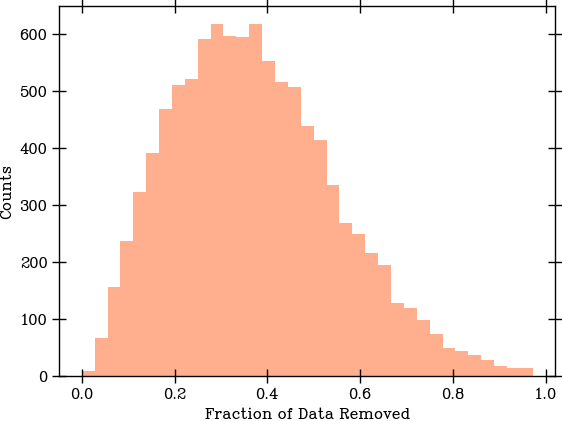

In [13]:
# Plot histogram of data flagged samples
plt.hist(flagged_samples, bins='scott', alpha=0.5)
plt.xlabel('Fraction of Data Removed')
plt.ylabel('Counts')
plt.show()

In [13]:
# Read in real simulated light curve 
sim_data = pd.read_csv('noisy_lc_with_outliers.csv')

In [14]:
sim_data

,# Times (days),True fluxes,Noisy fluxes A (sigma=0.01),Noisy fluxes B (sigma=0.02),Noisy fluxes C (sigma=0.03),Noisy fluxes D (sigma=0.05),Noisy fluxes E (sigma=0.07),Noisy fluxes A (sigma=0.01) with outliers (sigma=0.1),Noisy fluxes B (sigma=0.02) with outliers (sigma=0.1),Noisy fluxes C (sigma=0.03) with outliers (sigma=0.1),Noisy fluxes D (sigma=0.05) with outliers (sigma=0.1),Noisy fluxes E (sigma=0.07) with outliers (sigma=0.1),Noisy fluxes A (sigma=0.01) with outliers (sigma=0.3),Noisy fluxes B (sigma=0.02) with outliers (sigma=0.3),Noisy fluxes C (sigma=0.03) with outliers (sigma=0.3),Noisy fluxes D (sigma=0.05) with outliers (sigma=0.3),Noisy fluxes E (sigma=0.07) with outliers (sigma=0.3)
0,0.000000,0.762092,0.771425,0.788211,0.764792,0.728322,0.797965,0.771425,0.788211,0.764792,0.728322,0.683565,0.771425,0.788211,0.764792,0.728322,0.454766
1,0.003479,0.762282,0.773293,0.746130,0.760639,0.802119,0.819535,0.773293,0.746130,0.760639,0.802119,0.819535,0.773293,0.746130,0.760639,0.802119,0.819535
2,0.006958,0.762956,0.764405,0.729815,0.728571,0.819168,0.786933,0.731557,0.729815,0.728571,0.819168,0.786933,0.665862,0.729815,0.728571,0.819168,0.786933
3,0.010436,0.763841,0.745824,0.800916,0.749610,0.815238,0.801477,0.745824,0.800916,0.749610,0.815238,0.616126,0.745824,0.800916,0.749610,0.815238,0.245423
4,0.013915,0.765342,0.766261,0.774608,0.748873,0.688365,0.865938,0.766261,0.774608,0.748873,0.682440,0.865938,0.766261,0.774608,0.748873,0.670590,0.865938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3891,13.536085,0.765321,0.779462,0.785381,0.782964,0.664915,0.719379,0.779462,0.785381,0.782964,0.664915,0.719379,0.779462,0.785381,0.782964,0.664915,0.719379
3892,13.539564,0.763902,0.763061,0.750850,0.723304,0.671616,0.692695,0.763061,0.750850,0.723304,0.671616,0.692695,0.763061,0.750850,0.723304,0.671616,0.692695
3893,13.543042,0.762919,0.753216,0.762453,0.731271,0.771231,0.803816,0.753216,0.762453,0.731271,0.771231,0.803816,0.753216,0.762453,0.731271,0.771231,0.803816
3894,13.546521,0.762277,0.767508,0.780152,0.796230,0.720705,0.621073,0.694146,0.780152,0.796230,0.765850,0.621073,0.547423,0.780152,0.796230,0.856139,0.621073


In [15]:
t_arr = np.asarray(sim_data['# Times (days)'])*un.day
flux_true = np.asarray(sim_data['True fluxes'])
noisy_fluxes = np.asarray(sim_data['Noisy fluxes A (sigma=0.01)'])
noisy_fluxes_with_outliers = np.asarray(sim_data['Noisy fluxes A (sigma=0.01) with outliers (sigma=0.1)'])

In [16]:
# Apply mask 
dur_params = (20*un.min,45*un.min)
f = 6
flagged_samples = get_distribution_of_flagged_data(t_arr, flux_true, dur_params, f,nsample=int(1e3))

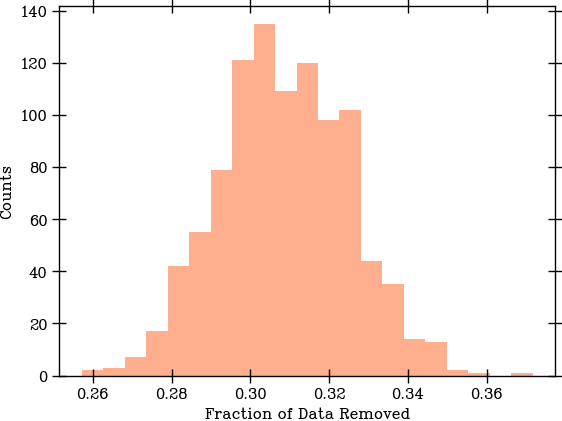

In [19]:
# Plot histogram of data flagged samples
plt.hist(flagged_samples, bins='scott', alpha=0.5)
plt.xlabel('Fraction of Data Removed')
plt.ylabel('Counts')
plt.show()

In [20]:
from scipy.stats import t
def get_confidence_interval(samples, confidence_interval=0.9):
    '''
    Compute the confidence interval on the mean of a set of samples following a student-t distribution. 

    Parameters: 
    -----------
    samples: ndarray 
        Array of samples to compute mean and confidence interval. 
    confidence_interval: float 
        Desired confidence interval 

    Returns: 
    --------
    interval: tuple
        Tuple containing estimator of mean, upper 90% CI, lower 90% CI
    '''

    # Compute estimator of mean and sample standard deviation
    estimator_mean = np.mean(samples)
    estimator_std = np.std(samples,ddof=1)

    n = len(samples)

    # Compute t statistic at alpha/2 
    alpha = 1 - confidence_interval 
    dof = int(n - 1)
    t_stat = t.ppf(alpha/2, dof)

    return estimator_mean, t_stat*estimator_std/np.sqrt(n), -1*t_stat*estimator_std/np.sqrt(n)

get_confidence_interval(flagged_samples)

(0.3086360369609856, -0.0008487187931271637, 0.0008487187931271637)

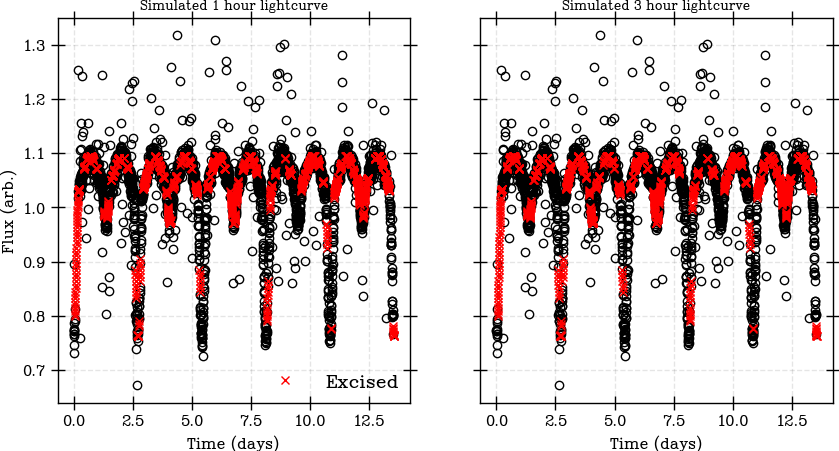

In [21]:
t_arr_masked, fluxes_masked, mask,_,nblocks = remove_data_random(t_arr, noisy_fluxes_with_outliers, dur_params, f=f,fill_nan=False)

# Generate simulation observation
fig, (ax1,ax2) = plt.subplots(figsize=(10,5), nrows=1,ncols=2,sharey=True)
ax1.plot(t_arr_masked, fluxes_masked, 'o',mew=1,mfc='none',color='black',ls='none')
ax1.plot(t_arr[~mask], flux_true[~mask],'x',color='red', label='Excised')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Flux (arb.)')
ax1.grid(alpha=0.1)
# ax1.set_xlim(0,60)
ax1.set_title('Simulated 1 hour lightcurve')
ax1.legend(fontsize=16)


ax2.plot(t_arr_masked, fluxes_masked, 'o',mew=1,mfc='none',color='black',ls='none')
ax2.plot(t_arr[~mask], flux_true[~mask],'x',color='red', label='Excised')
ax2.set_xlabel('Time (days)')
ax2.grid(alpha=0.1)
ax2.set_title('Simulated 3 hour lightcurve')


plt.show()


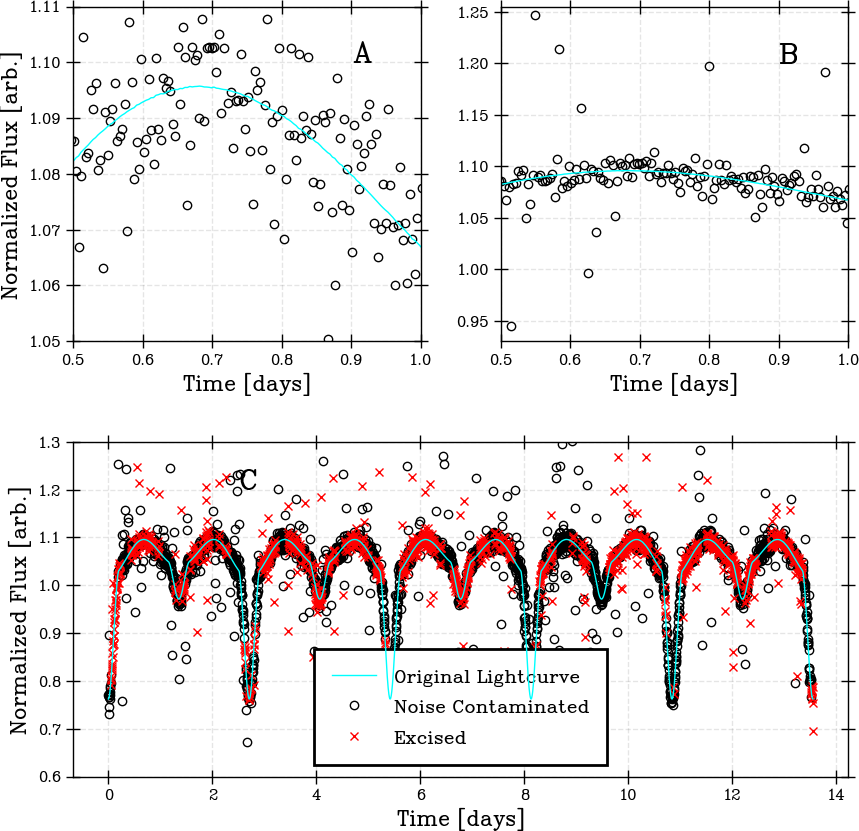

In [26]:
import matplotlib.gridspec as gridspec

ymin, ymax=0.7,1.3

plt.figure(figsize=(10,10))
gs = gridspec.GridSpec(2, 4)
gs.update(wspace=0.6,hspace=0.3)
ax1 = plt.subplot(gs[0, :2], )
ax2 = plt.subplot(gs[0, 2:])
ax3 = plt.subplot(gs[1, :])

# Plot in the first row
ax1.plot(t_arr, noisy_fluxes, 'o', mfc='none', mec='black')
ax1.plot(t_arr, flux_true, '-', color='cyan',lw=1)
ax1.set_xlim(0.5,1.0)
ax1.grid(alpha=0.1)
ax1.set_ylim(1.05,1.11)
ax1.set_xlabel('Time [days]', fontsize=18)
ax1.set_ylabel('Normalized Flux [arb.]',fontsize=18)

ax2.plot(t_arr, noisy_fluxes_with_outliers, 'o', mfc='none', mec='black')
ax2.plot(t_arr, flux_true, '-', color='cyan',lw=1)

ax2.set_xlim(0.5,1.0)
ax2.grid(alpha=0.1)
ax2.set_ylim(0.93,1.255)
ax2.set_xlabel('Time [days]', fontsize=18)
# ax2.set_ylabel('Normalized Flux [arb.]', fontsize=18)

# Merge the two columns in the second row
ax3.plot(t_arr, flux_true, '-', color='cyan',lw=1,label='Original Lightcurve',zorder=10)
ax3.plot(t_arr_masked, fluxes_masked, 'o',mew=1,mfc='none',color='black',ls='none',label='Noise Contaminated')
ax3.plot(t_arr[~mask], noisy_fluxes_with_outliers[~mask],'x',color='red', label='Excised')


ax3.legend(
    fontsize=16, 
    loc='lower center', 
    frameon=True,                      # Enables the legend frame
    facecolor='white',                 # White background
    edgecolor='black',                 # Black border
    framealpha=1,                      # Solid background (no transparency)
    fancybox=False,                    # Sharp corners (not rounded)
    borderpad=0.8                      # Padding inside the box
).get_frame().set_linewidth(2)   

# ax3.set_xlim(0,)
ax3.grid(alpha=0.1)
ax3.set_xlabel('Time [days]', fontsize=18)
ax3.set_ylabel('Normalized Flux [arb.]', fontsize=18)

ax3.set_ylim(0.6,ymax)


# # Add inset to first axis 
# axin = inset_axes(ax3, width="50%", height="50%", loc='lower left')  

# # Example data for inset (you can adjust as needed)
# axin.plot(t_arr, noisy_fluxes, 'o', mfc='none', mec='black')
# axin.plot(t_arr, flux_true, '-', color='cyan', lw=1)

# # Custom inset axis limits
# axin.set_xlim(0.5, 0.8)  # Zoomed-in region
# axin.set_ylim(1.05, 1.12)
# axin.grid(alpha=0.1)

# # Optional: Indicate zoomed region with a rectangle
# ax3.indicate_inset_zoom(axin, edgecolor='orange',lw=2,alpha=1)

ax1.text(0.9,1.1,'A',fontsize=25,fontweight='bold', color='black')
ax2.text(0.9,1.2,'B',fontsize=25,fontweight='bold', color='black')
ax3.text(2.5,1.2,'C',fontsize=25,fontweight='bold', color='black')


plt.savefig('sim_noise.png',dpi=200,bbox_inches='tight')
plt.show()


np.save('t_arr.npy', t_arr.value)
np.save('mask.npy', mask)
np.save('fluxes.npy', noisy_fluxes_with_outliers)



# **MCMC (using `emcee`)**

In [1]:
# Import relevant packages 
import emcee 
import phoebe as pb
from phoebe import u
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un
import scipy as sp 

pb.atmospheres.passbands._url_tables_server = 'https://staging.phoebe-project.org'
pb.list_online_passbands(refresh=True)
pb.list_all_update_passbands_available()
pb.update_all_passbands()



In [2]:
#1. Define model for a given set of input parameters (compute LC from phoebe) 
#2. Define log likelihood, log priors 
#3. Determine set of initial parameters 
#4. Run MCMC 
#5. Observe behavior of different priors 

### **Loading in ``real" data**

In [3]:
yfull = np.load('fluxes.npy') # Normalized
xfull = np.load('t_arr.npy') # units of days 
mask = np.load('mask.npy') 

xuse = xfull[mask]
yuse = yfull[mask]

In [4]:
### for a cadence of 5 mins:
def sample_number(t):
    return 2.71*24*60/t # [days] * [hours/day] * [mins/hour] / [mins]

# Define period 
period = 2.71
nperiods = 5
# Define sampling rate
tsamp = 100 #units?
nsamp = sample_number(tsamp)
print(nsamp)
logger = pb.logger()
b = pb.default_binary()
lcnum='lc01'
b.add_dataset('lc', times=pb.linspace(0,period,int(nsamp)), dataset=lcnum, overwrite=True)
### comment out these two lines after running once (if re-running cell)
b.flip_constraint("requivsumfrac@binary", solve_for="requiv@primary")
b.flip_constraint("teffratio@binary", solve_for = "teff@primary")

def upsample_lightcurve(x_upsampled,x,y): 
    '''
    Upsample lightcurve to new time resolution
    '''
    interpolated_lc = sp.interpolate.CubicSpline(x, y)
    return interpolated_lc(x_upsampled)

# Define PHOEBE model 
def get_phoebe_lightcurve(t,mask,Teff_ratio,requiv, ecc=1.6e-4, incl=77.3, period=period, gravb=0.9, irrad=0.9,nperiods=nperiods):
    
    #setting chosen binary parameters
    b["ecc@binary"] = ecc
    b["incl@binary"] = incl
    b["period@binary"] = period
    b['teffratio@binary'] = Teff_ratio
    b["requivsumfrac@binary@orbit@component"] = requiv
    
    b["gravb_bol@primary"] = gravb
    b["irrad_frac_refl_bol@primary"] = irrad

    b.run_compute()
    fluxes = b.get_value('fluxes@lc01@model') # normalized flux units
    _fluxes = b.get_value('fluxes@lc01@model') # normalized flux units
    times = b.get_value('times@lc01@model') # days 
    _times = b.get_value('times@lc01@model') # days 
    
        
    for i in range(nperiods-1): 
        fluxes = np.concatenate([fluxes,_fluxes[1:]])
        times = np.concatenate([times, _times[1:] + (i+1)*period])

    flux_model = upsample_lightcurve(t,times,fluxes)

    return flux_model
    

39.023999999999994


In [5]:
flux_model = get_phoebe_lightcurve(xuse,mask,0.65,0.483)

100%|███████████████████████████████████████████| 39/39 [00:01<00:00, 25.64it/s]


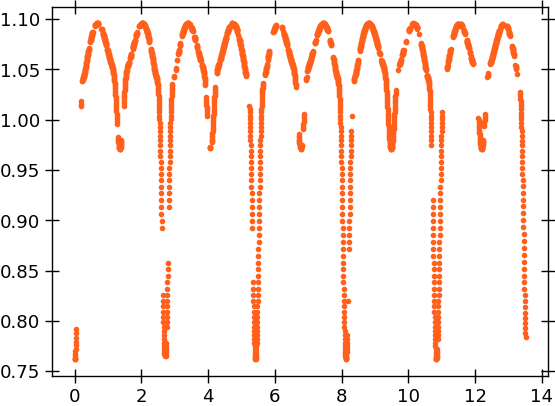

In [6]:
plt.plot(xuse, flux_model, '.')

## **Set up MCMC**

In [15]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm 

# Define the log-likelihood function
def log_likelihood(xuse, mask, flux, flux_err, Teff_ratio,requiv):    
    # Define period 
    period = 2.71
    nperiods = 5
    # Define sampling rate
    tsamp = 100 #units?
    nsamp = sample_number(tsamp)
    print(nsamp)
    logger = pb.logger()
    b = pb.default_binary()
    lcnum='lc01'
    b.add_dataset('lc', times=pb.linspace(0,period,int(nsamp)), dataset=lcnum, overwrite=True)
    ### comment out these two lines after running once (if re-running cell)
    b.flip_constraint("requivsumfrac@binary", solve_for="requiv@primary")
    b.flip_constraint("teffratio@binary", solve_for = "teff@primary")

    model_flux = get_phoebe_lightcurve(xuse,mask,Teff_ratio,requiv)
    residual = flux - model_flux
    logL = -0.5 * np.sum((residual / flux_err) ** 2 + np.log(2 * np.pi * flux_err ** 2))
    return logL

# Define the log-prior function with a Gaussian prior on f
def log_prior(Teff_ratio, requiv):

    # Assert uniform priors on ratio of Teff_ratio and requiv
    if Teff_ratio<0 or Teff_ratio>1: 
        return -np.inf 

    elif requiv<0 or requiv>1: 
        return -np.inf

    else: 
        return 0
        

# Define the log-posterior function
def log_posterior(params, xuse, mask, flux, flux_err):
    Teff_ratio,requiv = params
    lp = log_prior(Teff_ratio,requiv)

    # If outside of uniform prior, reject step
    if not np.isfinite(lp):
        return -np.inf

    # Phoebe has its own internal checks. If it raises an error, reject step 
    try: 
        llhd = log_likelihood(xuse, mask, flux, flux_err, Teff_ratio,requiv)
    except: 
        return -np.inf
        
    return lp + llhd


def guess_initial_pars(nwalkers, ndim=2): 

    initial_pos = np.empty((nwalkers,ndim))
    Teff_guess = 0.5 * 0.01*np.random.randn(nwalkers)
    requiv_guess = 0.5 * 0.01*np.random.randn(nwalkers)

    initial_pos[:,0] = Teff_guess
    initial_pos[:,1] = requiv_guess

    return initial_pos

In [16]:
ndim = 2 
nwalkers = 16 
nsteps = 100

p0 = guess_initial_pars(nwalkers,ndim)

# Import simulated light curve to act as "true data" 
yfull = np.load('fluxes.npy') # Normalized
xfull = np.load('t_arr.npy') # units of days 
mask = np.load('mask.npy') 
xuse = xfull[mask]
fluxes = yfull[mask]

# For uncertainties, let's assume the same for all data points, based off of our added gaussian noise (mean 0, std = 0.01)
flux_err = np.ones_like(fluxes)*0.01

# Initialize mcmc 
sampler = emcee.EnsembleSampler(nwalkers,ndim,log_posterior,args=(xuse,mask,fluxes,flux_err))

In [17]:
log_likelihood(xuse,mask, fluxes, flux_err, 1,0.5)

39.023999999999994


Tue, 25 Mar 2025 11:23 BUNDLE       WARNING overwriting model: latest
Tue, 25 Mar 2025 11:23 BUNDLE       WARNING 'primary' probably has a convective atm (teff=6000K<6600K), for which gravb_bol<0.9 (suggestion: 0.32) might be a better approx than gravb_bol=0.90.
Tue, 25 Mar 2025 11:23 BUNDLE       WARNING 'primary' probably has a convective atm (teff=6000K<=6600K), for which irrad_frac_refl_bol<0.75 (suggestion: 0.6) might be a better approx than irrad_frac_refl_bol=0.90.
100%|███████████████████████████████████████████| 39/39 [00:01<00:00, 25.84it/s]


-885680.4614576041

In [9]:
# Run mcmc 
# import warnings 
# warnings.filterwarnings(action="ignore") 

# with tqdm(total=nsteps) as pbar: 
#     for sample in sampler.sample(p0,iterations=nsteps,progress=False): 
#         pbar.update(1)

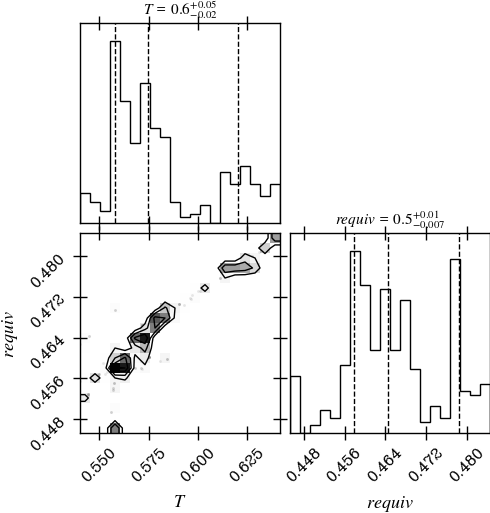

In [81]:
# Load in chains 
import corner 
# flat_samples = np.load('chains1.npy')
flat_samples = np.load('chains.npy')

# Define labels for corner plot
labels = [r"$T$", r"$requiv$"]

# Generate the corner plot
fig = corner.corner(flat_samples, labels=labels, show_titles=True,title_fmt=0.1, quantiles=[0.16, 0.5, 0.84])

# plt.savefig(f'corner_plot.png',dpi=150)
plt.show()

In [82]:
Teff_mcmc = np.percentile(flat_samples[:, 0], [16, 50, 84])
Requiv_mcmc = np.percentile(flat_samples[:, 1], [16, 50, 84])


def get_confidence_interval(percentiles): 

    median = percentiles[1]
    upper = percentiles[-1] - median 
    lower = median - percentiles[0]

    return median, upper, lower 
    

Teff_fit, upper_Teff, lower_Teff = get_confidence_interval(Teff_mcmc)
requiv_fit,upper_req,lower_req = get_confidence_interval(Requiv_mcmc)

# Compute model 
best_model_flux = get_phoebe_lightcurve(xfull,mask,Teff_fit,requiv_fit)

Tue, 25 Mar 2025 17:16 BUNDLE       WARNING overwriting model: latest
Tue, 25 Mar 2025 17:16 BUNDLE       WARNING ld_mode_bol of 'lookup' uses a bolometric passband which is not reliable for hot stars.  Consider using ld_mode_bol of manual and providing ld_coeffs instead.
100%|███████████████████████████████████████████| 39/39 [00:01<00:00, 26.84it/s]


In [83]:
print(r'''Best fit parameters: 
Teff = {0}(upper err): {1}, (lower err): {2}
Requiv = {3}(upper err): {4}, (lower err): {5}
      '''.format(
          Teff_fit,upper_Teff,lower_Teff,
         requiv_fit,upper_req,lower_req
                
                ))


print('''
True Parameters: 
----------------
Teff = 0.65
Requiv = 0.483
''')

Best fit parameters: 
Teff = 0.5745483734837584(upper err): 0.04597156656493129, (lower err): 0.016867019216100787
Requiv = 0.4645087591328547(upper err): 0.013898691821451592, (lower err): 0.0065910858385390125
      

True Parameters: 
----------------
Teff = 0.65
Requiv = 0.483



In [84]:
0.481 + 0.0008*2

0.4826

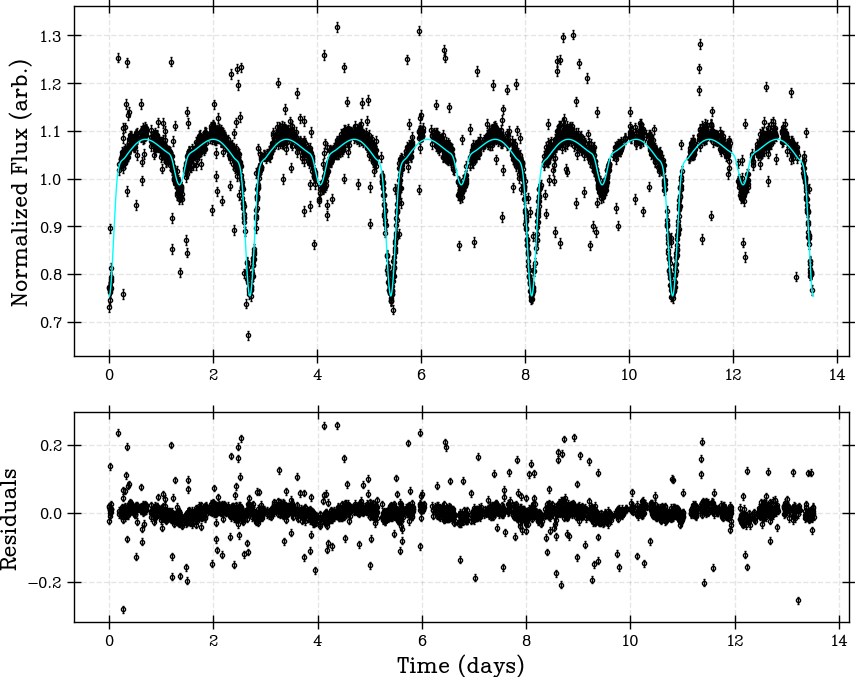

In [85]:
# Plot resulting fit on top of data 
xuse = xfull[mask]
yuse = yfull[mask]

# Compute residuals 
residuals = yuse - best_model_flux[mask]

# Plot fit, data and residuals 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2.5, 1.5]})

ax1.plot(xuse,yuse,'.',mew=1,mfc='none',color='black',ls='none')
ax1.errorbar(xuse,yuse,yerr=flux_err,capsize=1,alpha=1,color='black', fmt='none')
ax1.plot(xfull, best_model_flux,ls='-',color='cyan')


ax2.plot(xuse, residuals, '.', mew=1,mfc='none',color='black',ls='none')
ax2.errorbar(xuse, residuals, yerr=flux_err,capsize=1,alpha=1,color='black', fmt='none')
ax2.set_ylabel('Residuals',fontsize=18)

ax2.set_xlabel('Time (days)',fontsize=18)
ax1.set_ylabel('Normalized Flux (arb.)',fontsize=18)
ax1.grid(alpha=0.1)
ax2.grid(alpha=0.1)

plt.show()